In [ ]:
#  When working with lin. reg. we used:
#  y_pred = wX + b as our predicting function
#  MSE as our loss function
#
# However, if we have a binary classification task and need to classify 0 to 1, we should use:
#  y_pred = 1/(1 + e^(-z)), where z is a linear function
#  -1/n * ​∑[y * log(y_pred​) + (1−y) * log(1 − y_pred​)] as our loss function
#   The above loss function is called cross-entropy loss.

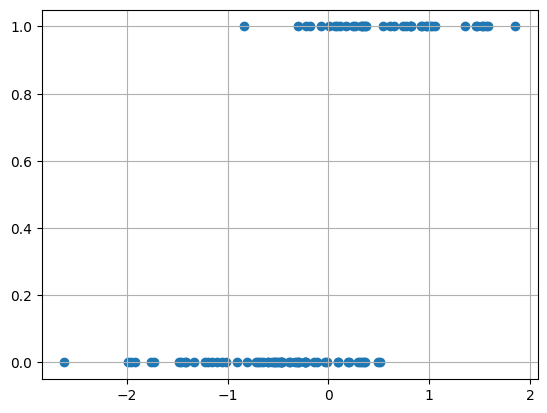

In [66]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.randn(100)
y = (X + np.random.randn(100) * 0.5 > 0).astype(float)

plt.scatter(X, y)
plt.grid()
plt.show()

In [67]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [68]:
w = 3
b = 5
gamma = 0.1

In [69]:
def compute_cross_entropy_loss(X, y, w, b):
  n = len(X)

  y_pred = sigmoid(w * X + b)

  return (-1 / n) * np.sum( (y * np.log(y_pred) ) + ( (1 - y) * (np.log(1 - y_pred)) ) )

In [70]:
def compute_gradients(X, y, w, b):

  n = len(X)
  y_pred = sigmoid(w * X + b)
  error = y_pred - y

  dw = (1/n) * np.dot(X, error)
  db = (1/n) * np.sum(error)

  return dw, db


Current loss: 1.9980
Current w and b: w = 3.0239, b = 4.9479
Current loss: 0.5550
Current w and b: w = 3.9489, b = 1.4217
Current loss: 0.3692
Current w and b: w = 3.9304, b = 0.1134
Current loss: 0.3451
Current w and b: w = 3.8453, b = -0.3514
Current loss: 0.3418
Current w and b: w = 3.7813, b = -0.5144
Current loss: 0.3413
Current w and b: w = 3.7344, b = -0.5695
Current loss: 0.3411
Current w and b: w = 3.6978, b = -0.5866
Current loss: 0.3410
Current w and b: w = 3.6681, b = -0.5905
Current loss: 0.3410
Current w and b: w = 3.6436, b = -0.5902
Current loss: 0.3409
Current w and b: w = 3.6232, b = -0.5888


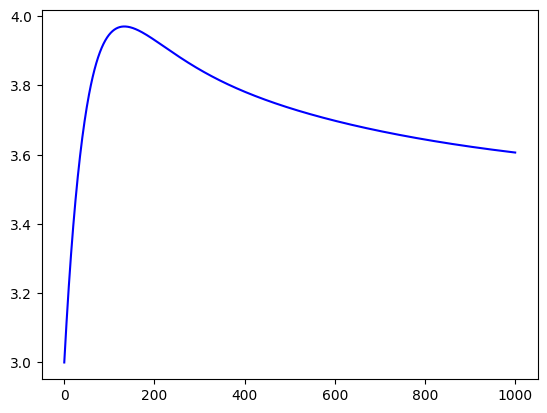

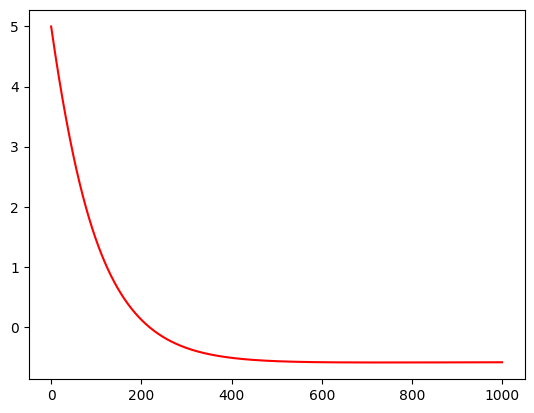

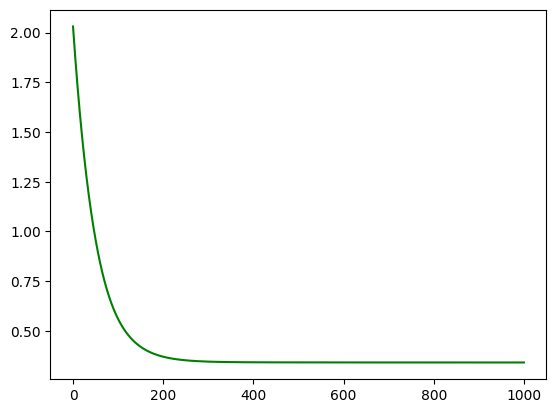

Predictive function after gradient descent: y = 1 / (1 + exp(3.6063 * X + -0.5871))
0.3409


In [71]:
steps_w = [w]
steps_b = [b]
losses = [compute_cross_entropy_loss(X, y, w, b)]

for epoch in range(1000):
  dw, db = compute_gradients(X, y, w, b)
  w = w - gamma * dw
  b = b - gamma * db

  loss = compute_cross_entropy_loss(X, y, w, b)
  losses.append(loss)
  steps_w.append(w)
  steps_b.append(b)

  if epoch % 100 == 0:
    print(f'Current loss: {loss:.4f}')
    print(f'Current w and b: w = {w:.4f}, b = {b:.4f}')


plt.plot(range(1001), steps_w, color='blue')
plt.show()
plt.plot(range(1001), steps_b, color='red')
plt.show()
plt.plot(range(1001), losses, color='green')
plt.show()


print(f"Predictive function after gradient descent: y = 1 / (1 + exp({w:.4f} * X + {b:.4f}))")
print(f'{compute_cross_entropy_loss(X, y, w, b):.4f}')

In [78]:
X_sorted = np.sort(X)

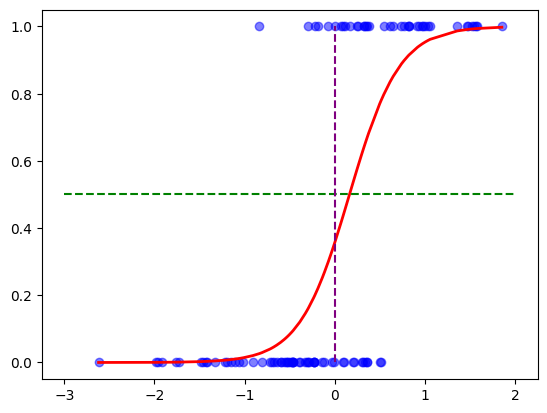

In [79]:
# Plot the prediction
plt.plot(X_sorted, sigmoid(w * X_sorted + b), color='red', linewidth=2.0)
plt.scatter(X, y, color='blue', alpha=0.5)
plt.hlines(xmin=-3, xmax=2, y=0.5, linestyle='--', color='green')
plt.vlines(ymin=0, ymax=1, x=0, linestyle='--', color='purple')
plt.show()

In [80]:
print(-b/w)

0.1627956288812195
